Import

In [1]:
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


import keras
import tensorflow as tf

In [2]:
tf.__version__


'2.19.0'

In [3]:
keras.__version__

'3.13.2'

In [4]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

# CNN 연습 1

*   Keras 패키지의 Fashion MNIST 데이터 셋
    *   훈련 셋과 테스트 셋의 데이터는 0. ~ 1. 스케일로 스케일링
*   CNN 모델 구조
    *   Conv2D(filters=64, kernel_size=7)
    *   MaxPool2D
    *   Conv2D(filters=128, kernel_size=3)
    *   Conv2D(filters=128, kernel_size=3)
    *   MaxPool2D
    *   Conv2D(filters=256, kernel_size=3)
    *   Conv2D(filters=256, kernel_size=3)
    *   MaxPool2D
    *   Flatten
    *   Dense(units=128)
    *   Dropout(rate=0.5)
    *   Dense(units=64)
    *   Dropout(rate=0.5)
    *   Dense - 출력층
    *   출력층을 제외한 층(Conv2D, Dense)들의 활성화 함수는 ReLU
    *   합성곱 층의 `padding` 방식은 'same' 방식.
    *   합성곱 층의 커널 초기화 함수(`kernel_initializer`)는 'he_normal'
*   모델 컴파일 시 `optimizer`는 Nadam으로 설정.
*   ModelCheckpoint, EarlyStopping 콜백을 사용해서 모델 훈련을 조기 종료하고, 최적의 모델은 best_cnn1.keras 파일에 저장.
*   각 에포크에서의 손실 함수를 시각화.
*   모델 성능 평가

## Fashion MNIST Datasets

In [5]:
(x_train_full, y_train_full), (x_test, y_test)= keras.datasets.fashion_mnist.load_data()

In [6]:
x_train_full.shape

(60000, 28, 28)

In [7]:
x_test.shape

(10000, 28, 28)

In [8]:
# 훈련 셋과 테스트 셋을 (n_samples, height, width, channels) 모양으로 변환하고 0.0~1.0스케일로 변환.
x_train_full_scaled=x_train_full.reshape((-1,28,28,1))/255.0
x_test_scaled=x_test.reshape((-1,28,28,1))/255.0

In [9]:
# 전체 훈련 셋을 훈련/검증 셋으로 분리
x_train, x_val, y_train, y_val=train_test_split(x_train_full_scaled,y_train_full,
                                                test_size=0.1,
                                                stratify=y_train_full,
                                                random_state=42
                                                )

In [10]:
x_train.shape

(54000, 28, 28, 1)

In [11]:
x_val.shape

(6000, 28, 28, 1)

## CNN 모델 생성

In [12]:
tf.random.set_seed(42)
np.random.seed(42)

In [13]:
cnn_1 = keras.Sequential(layers=[
    keras.Input(shape=(28,28,1)),
    keras.layers.Conv2D(filters=64, kernel_size=7, padding='same',
                        activation='relu',kernel_initializer='he_normal'),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Conv2D(filters=128, kernel_size=3, padding='same',
                        activation='relu',kernel_initializer='he_normal'),
    keras.layers.Conv2D(filters=128, kernel_size=3, padding='same',
                        activation='relu',kernel_initializer='he_normal'),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Conv2D(filters=256, kernel_size=3, padding='same',
                        activation='relu',kernel_initializer='he_normal'),
    keras.layers.Conv2D(filters=256, kernel_size=3, padding='same',
                        activation='relu',kernel_initializer='he_normal'),
    keras.layers.MaxPool2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128,activation='relu',kernel_initializer='he_normal'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64,activation='relu',kernel_initializer='he_normal'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10,activation='softmax')
])

In [14]:
cnn_1.summary()
#(7*7*1+1)*64
#(3*3*64+1)*128
#(3*3*128+1)*128
#(3*3*128+1)*256
#(3*3*256+1)*256

#(2304*128+128)
#(128*64+64)
#(64*10+10)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

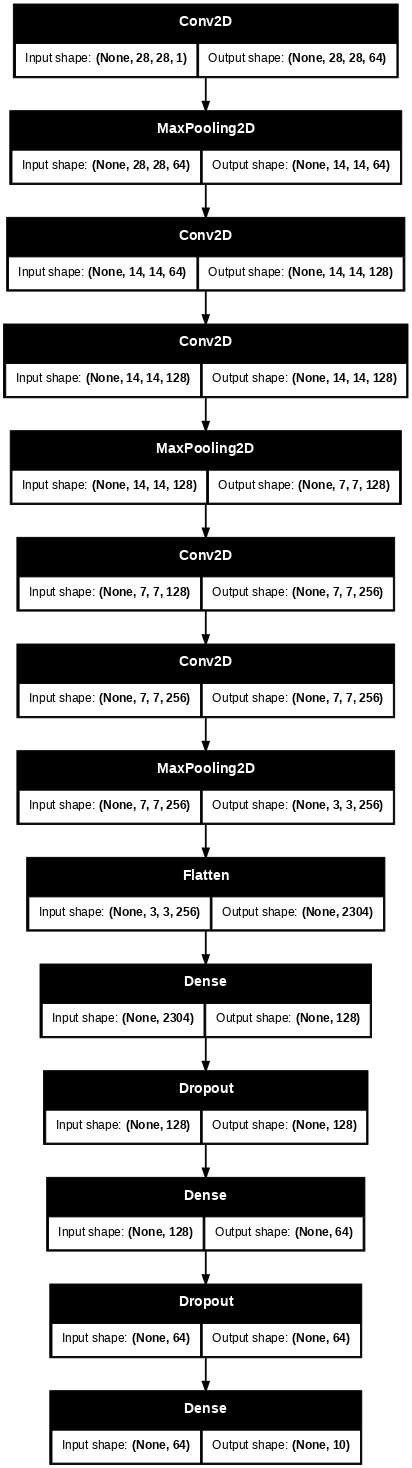

In [15]:
keras.utils.plot_model(model=cnn_1,dpi=64,show_shapes=True)
#

In [16]:
cnn_1.compile(optimizer=keras.optimizers.Nadam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

## CNN모델 훈련

In [17]:
dir='/content/drive/MyDrive/Colab Notebooks/lab_python/deeplearning'
file_name='best_cnn1'
suffix=datetime.now().strftime('%Y%m%d_%H%M%S') #예 202603201940
file_path=f'{dir}/{file_name}_{suffix}.keras'
print(file_path)

/content/drive/MyDrive/Colab Notebooks/lab_python/deeplearning/best_cnn1_20260321_001759.keras


In [18]:
checkpoint_cb=keras.callbacks.ModelCheckpoint(filepath=file_path, save_best_only=True)
early_stop_cb=keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [19]:
result=cnn_1.fit(x=x_train,y=y_train, batch_size=64,epochs=1000,
                 validation_data=[x_val,y_val],
                 callbacks=[checkpoint_cb,early_stop_cb])

Epoch 1/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 847s 998ms/step - loss: 0.8249 - sparse_categorical_accuracy: 0.7126 - val_loss: 0.3811 - val_sparse_categorical_accuracy: 0.8697
Epoch 2/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 824s 976ms/step - loss: 0.4546 - sparse_categorical_accuracy: 0.8476 - val_loss: 0.3129 - val_sparse_categorical_accuracy: 0.8938
Epoch 3/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 882s 1000ms/step - loss: 0.3663 - sparse_categorical_accuracy: 0.8768 - val_loss: 0.2571 - val_sparse_categorical_accuracy: 0.9133
Epoch 4/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 868s 1s/step - loss: 0.3228 - sparse_categorical_accuracy: 0.8924 - val_loss: 0.2588 - val_sparse_categorical_accuracy: 0.9070
Epoch 5/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 861s 1s/step - loss: 0.2846 - sparse_categorical_accuracy: 0.9052 - val_loss: 0.2424 - val_sparse_categorical_accuracy: 0.9102
Epoch 6/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 837s 991ms/step - loss: 0.2593 - sparse_categorical_accuracy: 0.9130 - val_loss: 0.2716 - val_sparse_ca

In [20]:
def plot_train_val_loss(history):
  # 파라미터 history: fit 메서드 리턴값(History 타입 객체)
  epochs=history.epoch
  history=history.history
  plt.plot(epochs, history['loss'],'bo-',label='train loss')
  plt.plot(epochs, history['val_loss'],'ro:',label='validation loss')

  plt.legend()
  plt.grid()
  plt.xlabel('epoch')
  plt.ylabel('loss')
  plt.show()

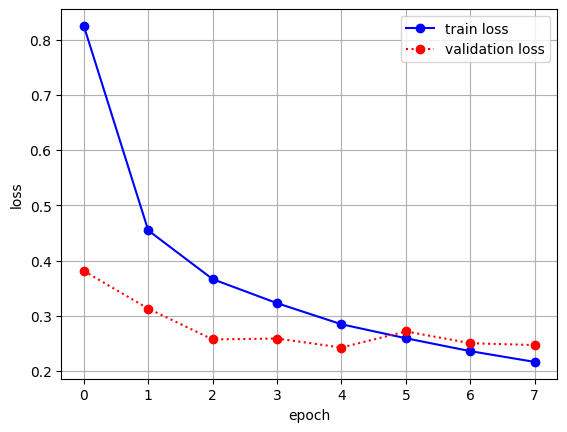

In [21]:
plot_train_val_loss(result)

## CNN 모댈 평가

In [22]:
# 훈련 샛 평가(손실, 정확도)
cnn_1.evaluate(x=x_train,y=y_train)

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 221s 131ms/step - loss: 0.2126 - sparse_categorical_accuracy: 0.9220


[0.21257568895816803, 0.9219814538955688]

In [23]:
# 검증 셋 평가
cnn_1.evaluate(x=x_val,y=y_val)

188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 134ms/step - loss: 0.2424 - sparse_categorical_accuracy: 0.9102


[0.24243861436843872, 0.9101666808128357]

# CNN 연습 2

*   Keras 패키지의 손글씨 MNIST 예제 데이터셋
    *   예제 데이터셋의 일부(예: 100개)를 시각화.
    *   훈련 셋과 테스트 셋의 데이터는 0. ~ 1. 스케일로 스케일링.
*   CNN 모델 구조
    *   Conv2D(filters=32, kernel_size=3)
    *   Conv2D(filters=64, kernel_size=3)
    *   MaxPool2D
    *   Flatten
    *   Dropout(rate=0.25)
    *   Dense(units=128)
    *   Dropout(rate=0.5)
    *   Dense - 출력층
*   모든 합성곱 층(Conv2D)와 출력층을 제외한 밀집층(Dense)에서
    *   활성화 함수(`activation`)는 ReLU로 설정.
    *   커널 초기화 함수(`kernel_initializer`)를 'he_normal'로 설정.
*   모델의 옵티마이저(`optimizer`)는 Nadam을 사용.
*   ModelCheckpoint, EarlyStopping 콜백을 함께 사용해서 모델을 훈련을 조기종료 하고, 최적의 모델은 best_cnn2.keras 파일에 저장.
*   각 에포크에서의 손실 함수를 시각화.
*   모델의 성능을 평가.

## 손글씨 MNIST Datasets

In [24]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [25]:
x_train_full.shape

(60000, 28, 28)

In [26]:
x_test.shape

(10000, 28, 28)

In [27]:
def plot_mnist_image(arr, ncols=10):
    # arr: (n_samples, height, width) 모양의 배열.
    n_samples = len(arr)
    nrows = int(np.ceil(n_samples / ncols))
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols, nrows))
    for i in range(nrows):
        for j in range(ncols):
            idx = i * ncols + j
            if nrows == 1 or ncols == 1:
                if idx < n_samples:
                    ax[idx].imshow(arr[idx], cmap=plt.cm.binary)
                ax[idx].axis('off')
            else:
                if idx < n_samples:
                    ax[i, j].imshow(arr[idx], cmap=plt.cm.binary)
                ax[i, j].axis('off')
    plt.show()

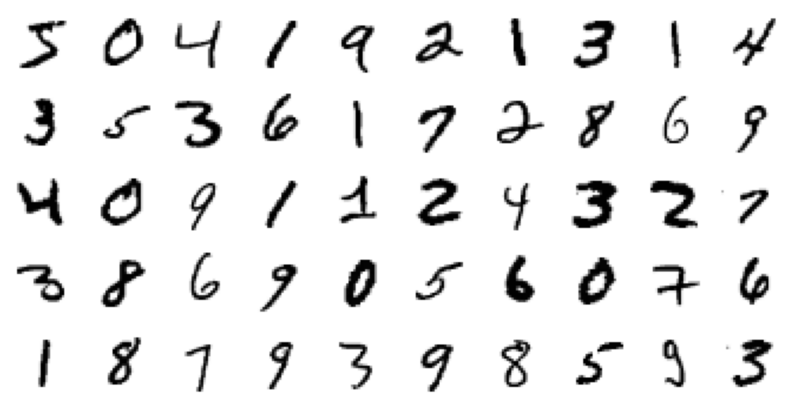

In [28]:
plot_mnist_image(x_train_full[:50])

In [29]:
# 훈련 셋과 테스트 셋의 모양은 (n_samples, height, width, channels), 스케일은 0.0 ~ 1.0으로 변환
x_train_full_scaled = x_train_full.reshape((-1, 28, 28, 1)) / 255.0
x_test_scaled = x_test.reshape((-1, 28, 28, 1)) / 255.0

In [30]:
# 전체 훈련 셋을 훈련/검증 셋으로 분리
x_train, x_val, y_train, y_val = train_test_split(x_train_full_scaled, y_train_full,
                                                  test_size=0.1,
                                                  stratify=y_train_full,
                                                  random_state=42)

In [31]:
x_train.shape

(54000, 28, 28, 1)

In [32]:
x_val.shape

(6000, 28, 28, 1)

## CNN 모델 생성

In [33]:
tf.random.set_seed(42)
np.random.seed(42)

In [34]:
cnn_2 = keras.Sequential(layers=[
    keras.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(filters=32, kernel_size=3, padding='same',
                        activation='relu', kernel_initializer='he_normal'),
    keras.layers.Conv2D(filters=64, kernel_size=3, padding='same',
                        activation='relu', kernel_initializer='he_normal'),
    keras.layers.MaxPool2D(),
    keras.layers.Flatten(),
    keras.layers.Dropout(rate=0.25),
    keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal'),  # 밀집층
    keras.layers.Dropout(rate=0.5),
    keras.layers.Dense(units=10, activation='softmax')
])

In [35]:
cnn_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,866 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

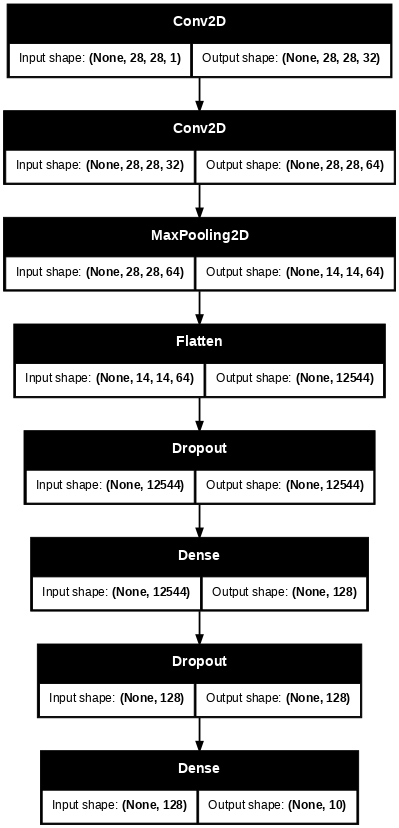

In [36]:
keras.utils.plot_model(model=cnn_2, show_shapes=True, dpi=64)

## 모델 훈련

In [37]:
# 모델 컴파일
cnn_2.compile(optimizer=keras.optimizers.Nadam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [38]:
dir = '/content/drive/MyDrive/Colab Notebooks/lab_python/deeplearning'
file_name = 'best_cnn2'
time_suffix = datetime.now().strftime('%Y%m%d%H%M%S')
file_path = f'{dir}/{file_name}_{time_suffix}.keras'
print(file_path)

/content/drive/MyDrive/Colab Notebooks/lab_python/deeplearning/best_cnn2_20260321021659.keras


In [39]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath=file_path, save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [40]:
result = cnn_2.fit(x=x_train, y=y_train, batch_size=64, epochs=1_000,
                   callbacks=[checkpoint_cb, early_stop_cb],
                   validation_data=[x_val, y_val])

Epoch 1/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 206s 242ms/step - loss: 0.2260 - sparse_categorical_accuracy: 0.9317 - val_loss: 0.0690 - val_sparse_categorical_accuracy: 0.9803
Epoch 2/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 204s 242ms/step - loss: 0.0891 - sparse_categorical_accuracy: 0.9729 - val_loss: 0.0578 - val_sparse_categorical_accuracy: 0.9848
Epoch 3/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 206s 244ms/step - loss: 0.0689 - sparse_categorical_accuracy: 0.9786 - val_loss: 0.0488 - val_sparse_categorical_accuracy: 0.9862
Epoch 4/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 264s 246ms/step - loss: 0.0541 - sparse_categorical_accuracy: 0.9834 - val_loss: 0.0421 - val_sparse_categorical_accuracy: 0.9885
Epoch 5/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 259s 243ms/step - loss: 0.0448 - sparse_categorical_accuracy: 0.9858 - val_loss: 0.0492 - val_sparse_categorical_accuracy: 0.9872
Epoch 6/1000
844/844 ━━━━━━━━━━━━━━━━━━━━ 203s 240ms/step - loss: 0.0378 - sparse_categorical_accuracy: 0.9878 - val_loss: 0.0448 - val_spar

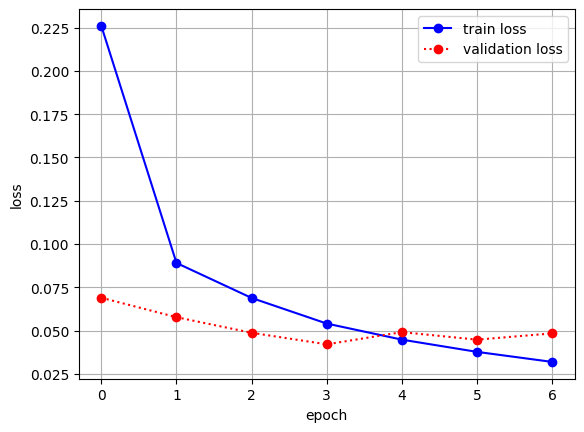

In [41]:
plot_train_val_loss(result)

## 모델 평가

In [42]:
# 훈련 셋 평가
cnn_2.evaluate(x=x_train, y=y_train)

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 55s 33ms/step - loss: 0.0131 - sparse_categorical_accuracy: 0.9958


[0.013107708655297756, 0.9958333373069763]

In [43]:
# 검증 셋 평가
cnn_2.evaluate(x=x_val, y=y_val)

188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0421 - sparse_categorical_accuracy: 0.9885


[0.042133551090955734, 0.9884999990463257]

유명한 CNN
*   LeNet-5
*   AlexNet
*   GoogLeNet
*   VGGNet
*   ResNet
*   Xception
*   SENet